<a href="https://colab.research.google.com/github/angelaportillo/LabPDI_IB/blob/main/P7_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de PDI *"Practica 7: Segmentación óptima"*
## Hora: N5 Carrera: IB Brigada: 509
###Integrantes del equipo:
*2028256 Angela Marisa Zapata Portillo*

*2016872 Marian Roxana Martínez Serrato*

*2006071 Gabriela Mariana Rangel Carrillo*


### Docente: Ing. Noe Adiel Ponce Moreno

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Imagen cargada correctamente


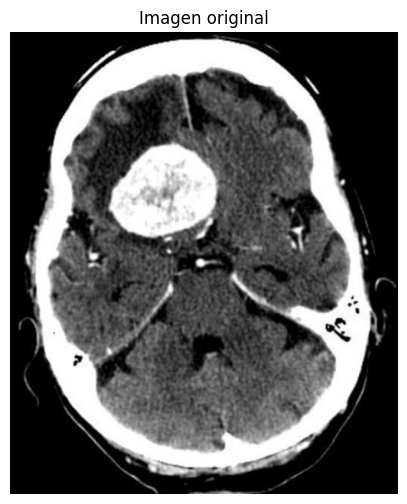

In [42]:
# Cargar la imagen
img = cv2.imread('/content/Te-me_0015.jpg')

# Verificar imagen
if img is None:
    print("ERROR: No se pudo cargar la imagen")
else:
    print("Imagen cargada correctamente")

# Convertir BGR -> RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')
plt.show()

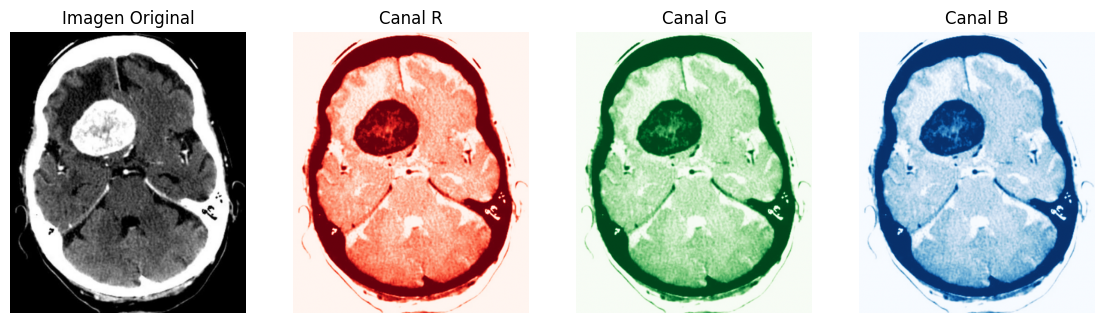

In [43]:
# SEPARAR CANALES RGB

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# Mostrar canales
plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(R, cmap='Reds')
plt.title('Canal R')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(G, cmap='Greens')
plt.title('Canal G')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(B, cmap='Blues')
plt.title('Canal B')
plt.axis('off')

plt.show()

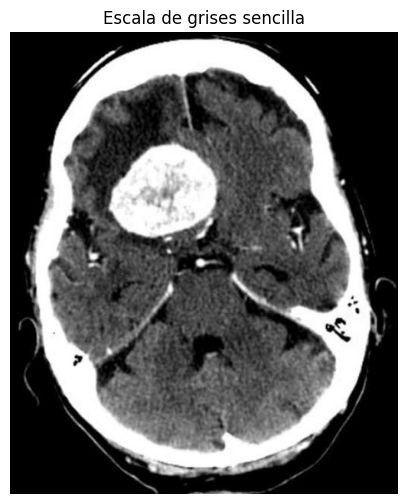

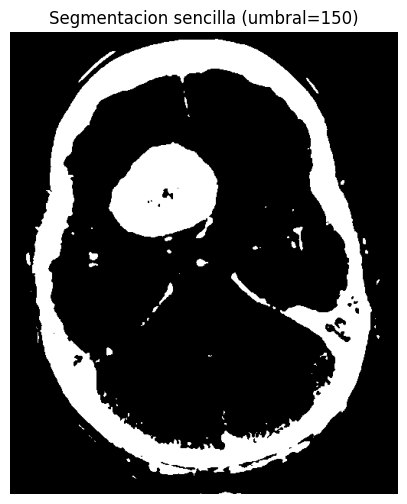

In [81]:
# SEGMENTACION SENCILLA

# Escala de grises simple
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises sencilla')
plt.axis('off')
plt.show()

# Umbral sencillo
umbral = 150

_, seg_simple = cv2.threshold(
    gray_avg,
    umbral,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(seg_simple, cmap='gray')
plt.title(f'Segmentacion sencilla (umbral={umbral})')
plt.axis('off')
plt.show()

In [82]:
# SEGMENTACION OPTIMA

# Normalizar canales
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

# Funcion objetivo
def grayscale_variance(weights):

    w_r, w_g, w_b = weights

    gray = (
        w_r * R_norm +
        w_g * G_norm +
        w_b * B_norm
    )

    gray_normalized = (
        (gray - gray.min()) /
        (gray.max() - gray.min())
    )

    return -np.var(gray_normalized)

# Restriccion
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

# Limites
bounds = [(0,1), (0,1), (0,1)]

# Pesos iniciales
initial_weights = [0.33, 0.33, 0.34]

# Optimizacion
result = minimize(
    grayscale_variance,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Pesos optimos
optimal_weights = result.x

print("Pesos optimos:")
print("R =", optimal_weights[0])
print("G =", optimal_weights[1])
print("B =", optimal_weights[2])

Pesos optimos:
R = 0.33
G = 0.33
B = 0.34


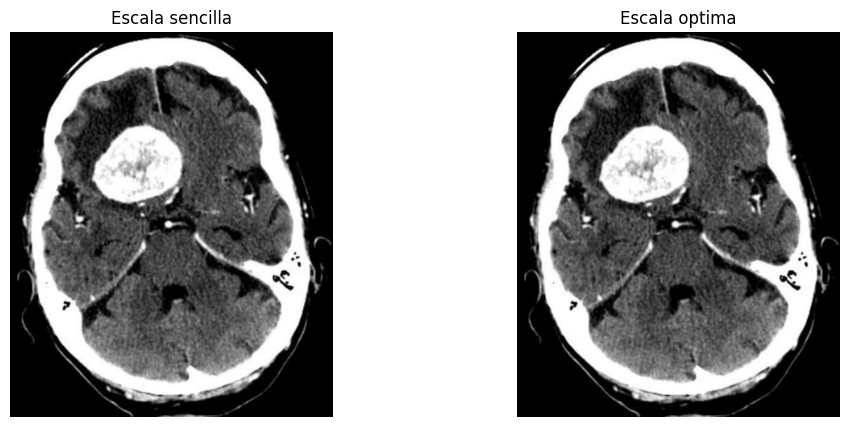

In [83]:
# ESCALA DE GRISES OPTIMA

gray_optimal = (
    optimal_weights[0] * R_norm +
    optimal_weights[1] * G_norm +
    optimal_weights[2] * B_norm
)

gray_optimal = (gray_optimal * 255).astype(np.uint8)

# Comparacion
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala sencilla')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala optima')
plt.axis('off')

plt.show()

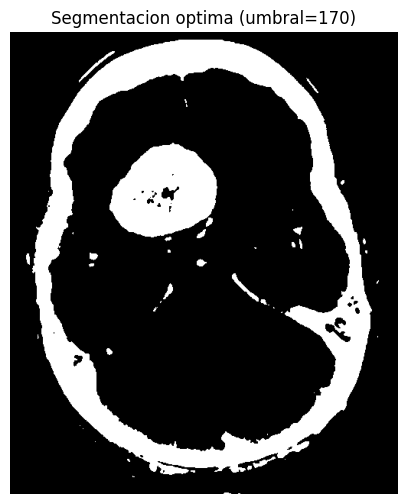

In [84]:
# SEGMENTACION OPTIMA BINARIA

umbral_optimo = 170

_, seg_optimal = cv2.threshold(
    gray_optimal,
    umbral_optimo,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentacion optima (umbral={umbral_optimo})')
plt.axis('off')
plt.show()

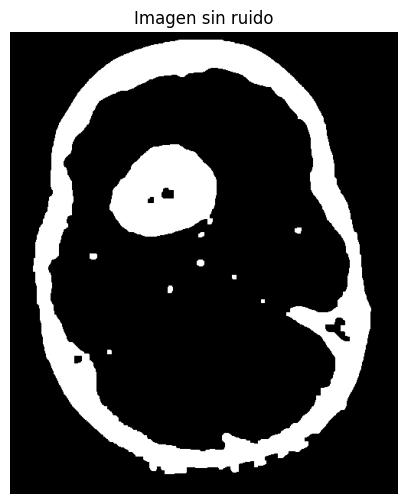

In [85]:
# ELIMINACION DE RUIDO

kernel = np.ones((5,5), np.uint8)

clean = cv2.morphologyEx(
    seg_optimal,
    cv2.MORPH_OPEN,
    kernel
)

clean = cv2.morphologyEx(
    clean,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap='gray')
plt.title('Imagen sin ruido')
plt.axis('off')
plt.show()

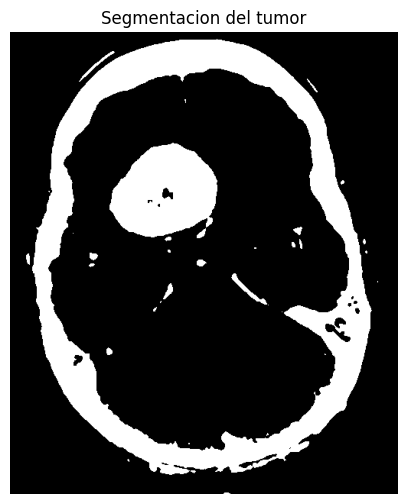

In [101]:
# DETECCION DEL TUMOR

# Suavizar imagen
blur = cv2.GaussianBlur(gray_optimal, (5,5), 0)

# Umbral para detectar regiones brillantes
_, tumor_thresh = cv2.threshold(
    blur,
    160,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(tumor_thresh, cmap='gray')
plt.title('Segmentacion del tumor')
plt.axis('off')
plt.show()

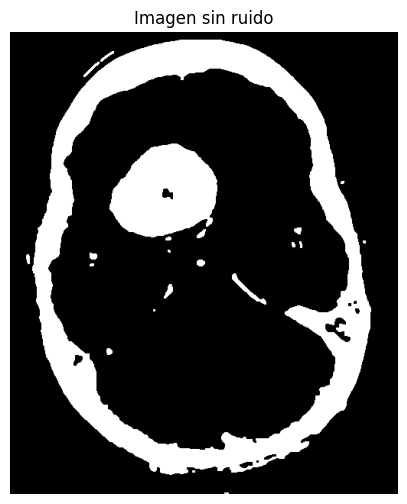

Area: 50753
Area: 73
Area: 97
Area: 12554
Area: 18
Area: 69
Area: 81
Area: 34
Area: 15
Area: 29
Area: 28
Area: 14
Area: 76
Area: 54
Area: 81
Area: 22
Area: 324
Area: 116
Area: 9
Area: 59
Area: 12
Area: 12


In [102]:
# ELIMINAR RUIDO

kernel = np.ones((3,3), np.uint8)

tumor_clean = cv2.morphologyEx(
    tumor_thresh,
    cv2.MORPH_OPEN,
    kernel
)

tumor_clean = cv2.morphologyEx(
    tumor_clean,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(tumor_clean, cmap='gray')
plt.title('Imagen sin ruido')
plt.axis('off')
plt.show()

# COMPONENTES CONECTADOS

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    tumor_clean,
    connectivity=8
)


# BUSCAR EL TUMOR

tumor_label = None
best_area = 0

height, width = gray_optimal.shape

for i in range(1, num_labels):

    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    cx, cy = centroids[i]

    print("Area:", area)

    # Ignorar regiones pequeñas
    if area > 80:

        # Ignorar regiones pegadas al borde
        if (
            x > 20 and
            y > 20 and
            x + w < width - 20 and
            y + h < height - 20
        ):

            # Escoger la region interna mas grande
            if area > best_area:

                best_area = area
                tumor_label = i

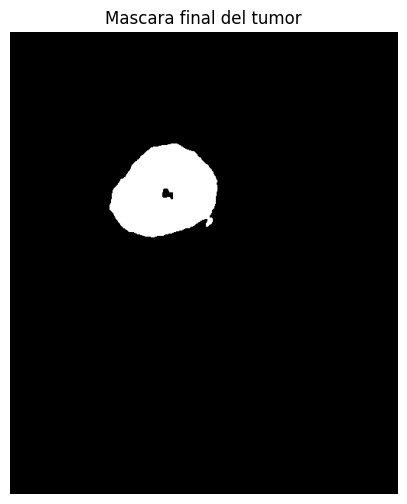

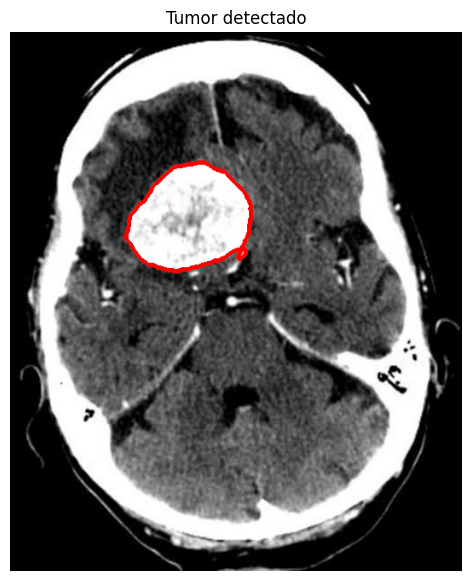

Area aproximada del tumor:
12554 pixeles


In [103]:
# CREAR MASCARA DEL TUMOR

mask = np.zeros(gray_optimal.shape, dtype=np.uint8)

if tumor_label is not None:

    mask[labels == tumor_label] = 255

    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap='gray')
    plt.title('Mascara final del tumor')
    plt.axis('off')
    plt.show()

    # ==========================================================
    # CONTORNO DEL TUMOR
    # ==========================================================

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    img_tumor = img_rgb.copy()

    cv2.drawContours(
        img_tumor,
        contours,
        -1,
        (255,0,0),
        3
    )

    plt.figure(figsize=(7,7))
    plt.imshow(img_tumor)
    plt.title('Tumor detectado')
    plt.axis('off')
    plt.show()

    # ==========================================================
    # AREA DEL TUMOR
    # ==========================================================

    tumor_area = cv2.countNonZero(mask)

    print("Area aproximada del tumor:")
    print(tumor_area, "pixeles")

else:

    print("No se detecto ningun tumor")